# Material stockpiling during a technology ramp-up

 In this application of the ETHOS.FINE framework, a transformation pathway of a energy system is modeled and optimized.

 All classes which are available to the user are utilized and examples of the selection of different parameters within these classes are given.

 The workflow is structures as follows:
 1. Required packages are imported and the input data path is set
 2. An energy system model instance is created
 3. Commodity sources are added to the energy system model
 4. Commodity conversion components are added to the energy system model
 5. Commodity storages are added to the energy system model
 6. Commodity sinks are added to the energy system model
 7. Material sinks are added to the energy system model
 8. Material sources are addeed to the energy system model
 9. Material conversions are added to the energy system model for recycling processes
 10. The energy system model is optimized
 11. Selected optimization results are presented


 # 1. Import required packages and set input data path

 The ETHOS.FINE framework is imported which provides the required classes and functions for modeling the energy system.

In [30]:
import fine as fn
from getData import getData
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


cwd = Path.cwd()
data = getData()

 # 2. Create an energy system model instance

 The structure of the energy system model is given by the considered locations, commodities, the number of time steps as well as the hours per time step.

 The commodities are specified by a unit (i.e. 'GW_electric', 'GW_H2lowerHeatingValue', 'Mio. t CO2/h') which can be given as an energy or mass unit per hour. Furthermore, the cost unit and length unit are specified.

In [31]:
locations = {"GermanyRegion"}
commodityUnitsDict = {
    "electricity": r"GW$_{el}$",
    "methane": r"GW$_{CH_{4},LHV}$",
    "CO2": r"Mio. t$_{CO_2}$/h",
}
commodities = {"electricity", "methane", "CO2"}
materials = {"steel"}
materialUnitsDict = {"steel": "tons/h"}

numberOfTimeSteps = 8760
hoursPerTimeStep = 1


 # 2.1 define Transformation Pathway parameters

 Transformation Pathway Analyses can be run by setting a number of investment periods
 larger than 1, which is the default value and results in a single year optimization.

In [32]:
numberOfInvestmentPeriods = 6
startYear = 2020
interval = 1
includeMaterialStorage = True
useTSA = True
numberOfTypicalPeriods = 30


In [33]:
pathwayBalanceLimit = pd.DataFrame(
    columns=["GermanyRegion", "Total", "lowerBound"],
    index=["Steel_Resources"],
)
pathwayBalanceLimit.loc["Steel_Resources"] = [None, None, False]

co2Budgets = {
    2020: 10.370918,
    2021: 0.8 * 10.370918,
    2022: 0.6 * 10.370918,
    2023: 0.4 * 10.370918,
    2024: 0.2 * 10.370918,
    2025: 0,
}
balanceLimit = {
    year: pd.DataFrame(
        {"Total": [-budget], "lowerBound": [True]},
        index=["CO2 limit"],
    )
    for year, budget in co2Budgets.items()
}


In [34]:
esM = fn.EnergySystemModel(
    locations=locations,
    commodities=commodities,
    materials=materials,
    numberOfInvestmentPeriods=numberOfInvestmentPeriods,
    startYear=startYear,
    investmentPeriodInterval=interval,
    numberOfTimeSteps=8760,
    commodityUnitsDict=commodityUnitsDict,
    materialUnitsDict=materialUnitsDict,
    hoursPerTimeStep=1,
    costUnit="1e9 Euro",
    lengthUnit="km",
    verboseLogLevel=0,
    balanceLimit=balanceLimit,
    pathwayBalanceLimit=pathwayBalanceLimit,
)

 # 3. Add commodity sources to the energy system model

 ## 3.1. Electricity sources

 ### Wind onshore

 change weather conditions for the different investment periods

In [35]:
operationRateMax = {
    2020: 1.2 * data["Wind (onshore), operationRateMax"],
    2021: 1.2 * data["Wind (onshore), operationRateMax"],
    2022: 1.2 * data["Wind (onshore), operationRateMax"],
    2023: 1.2 * data["Wind (onshore), operationRateMax"],
    2024: 1.2 * data["Wind (onshore), operationRateMax"],
    2025: 1.2 * data["Wind (onshore), operationRateMax"],
}


 add wind onshore source to esM

In [36]:
esM.add(
    fn.Source(
        esM=esM,
        name="windonshore",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=operationRateMax,
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=3.1,
        opexPerCapacity=3.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
        technicalLifetime=20,
        materialIntensity={
            2020: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2021: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2022: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2023: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2024: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
            2025: {
                "steel": pd.Series({"GermanyRegion": 3.1}),
            },
        },
        materialCollection={
            2020: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2021: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2022: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2023: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2024: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
            2025: {
                "steel": pd.Series({"GermanyRegion": 0.7}),
            },
        },
    )
)


In [37]:
esM.add(
    fn.Source(
        esM=esM,
        name="Natural gas purchase",
        commodity="methane",
        hasCapacityVariable=False,
        commodityCost=0.0331 * 1e-3,
    )
)

esM.add(
    fn.Conversion(
        esM=esM,
        name="Gas power plant",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={
            "electricity": 1,
            "methane": -1 / 0.6,
            "CO2": 201 * 1e-6 / 0.6,
        },
        hasCapacityVariable=True,
        investPerCapacity=0.65,
        opexPerCapacity=0.021,
        interestRate=0.08,
        economicLifetime=33,
    )
)

esM.add(
    fn.Sink(
        esM=esM,
        name="CO2 to environment",
        commodity="CO2",
        hasCapacityVariable=False,
        balanceLimitID="CO2 limit",
    )
)


 Full load hours:

In [38]:
data["Wind (onshore), operationRateMax"].sum()

np.float64(2300.4069071646272)

 # 4. Add conversion components to the energy system model

 ### Electrolyzers

 add component with constant invest and opex per capacity

 # 5. Add commodity storages to the energy system model

 ## 5.1. Electricity storage

 ### Lithium ion batteries

 The self discharge of a lithium ion battery is here described as 3% per month. The self discharge per hours is obtained using the equation (1-$\text{selfDischarge}_\text{hour})^{30*24\text{h}} = 1-\text{selfDischarge}_\text{month}$.

In [39]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Li-ion batteries",
        commodity="electricity",
        hasCapacityVariable=True,
        chargeEfficiency=0.95,
        cyclicLifetime=10000,
        dischargeEfficiency=0.95,
        selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
        chargeRate=1,
        dischargeRate=1,
        doPreciseTsaModeling=False,
        investPerCapacity=0.151,
        opexPerCapacity=0.002,
        interestRate=0.08,
        economicLifetime=15,
    )
)

 ## 5.2. Hydrogen storage

 ### Hydrogen filled salt caverns
 The maximum capacity is here obtained by: dividing the given capacity (which is given for methane) by the lower heating value of methane and then multiplying it with the lower heating value of hydrogen.

 # 6. Add commodity sinks to the energy system model

 ## 6.1. Electricity sinks

 ### Electricity demand

 vary the demand with the years - increasing demand by 30% per year

In [40]:
electricityDemand = {
    2020: data["Electricity demand, operationRateFix"],
    2021: data["Electricity demand, operationRateFix"],
    2022: data["Electricity demand, operationRateFix"],
    2023: data["Electricity demand, operationRateFix"],
    2024: data["Electricity demand, operationRateFix"],
    2025: data["Electricity demand, operationRateFix"],
}

esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=electricityDemand,
    )
)


 ## 6.2. Hydrogen sinks

 ### Fuel cell electric vehicle (FCEV) demand

# 7. Add material sinks to the energy system model

In [41]:
esM.generationMaterialSinks()

Existing material sinks: set()
Missing materials sinks: {'steel'}
New sink added: Steel demand


# 8. Add material sources to the energy system model


## 8.1 Add a capacity-constrained primary steel source

The mine can produce 16.2 tons per year. Across all six periods this is sufficient for the cumulative steel demand, but it is below the demand in each wind-expansion year.

In [42]:
annualSteelProduction = 16.2
steelSupplyOperationRateMax = {
    year: pd.DataFrame(
        annualSteelProduction / numberOfTimeSteps,
        index=range(numberOfTimeSteps),
        columns=["GermanyRegion"],
    )
    for year in esM.investmentPeriodNames
}

esM.add(
    fn.Source(
        esM=esM,
        name="Steel supply",
        hasCapacityVariable=False,
        commodity="steel",
        operationRateMax=steelSupplyOperationRateMax,
    )
)


In [43]:
esM.generationSecondaryMaterialSources()

Scrap commodities : {'windonshore_steel_scrap'}
Existing secondary material sources: set()
Missing secondary material sources: {'windonshore_steel_scrap'}
New scrap source added: windonshore_steel_scrap
Existing secondary material sinks: set()
Missing secondary material sinks: {'windonshore_steel_scrap'}
New scrap sink added: windonshore_steel_scrap_rec


# 9. Add material storages

Steel production is constant and dispatchable, but its annual production limit is below the steel demand during the wind ramp-up. Material produced before the demand occurs therefore has to be stockpiled.


In [44]:
if includeMaterialStorage:
    esM.add(
        fn.MaterialStorage(
            esM=esM,
            name="Steel storage",
            commodity="steel",
            hasCapacityVariable=True,
            chargeEfficiency=1,
            dischargeEfficiency=1,
            selfDischarge=0,
            stateOfChargeBoundary="interInvestmentPeriodNotCyclic",
            investPerCapacity=1e-7,
            opexPerCapacity=2e-9,
            opexPerChargeOperation=1e-9,
            opexPerDischargeOperation=1e-9,
            interestRate=0.08,
            economicLifetime=30,
            technicalLifetime=30,
        )
    )


# 10. Add recycling plants

 # 11. Optimize energy system model

 All components are now added to the model and the model can be optimized. If the computational complexity of the optimization should be reduced, the time series data of the specified components can be clustered before the optimization and the parameter timeSeriesAggregation is set to True in the optimize call.

In [45]:
if useTSA:
    esM.aggregateTemporally(
        numberOfTypicalPeriods=numberOfTypicalPeriods
    )



Clustering time series data with 30 typical periods and 24 time steps per period 
further clustered to 12 segments per period...
		(1.0500 sec)



In [46]:
esM.optimize(
    timeSeriesAggregation=useTSA,
    solver="gurobi",
)


Time series aggregation specifications:
Number of typical periods:30, number of time steps per period:24, number of segments per period:12

Declaring sets, variables and constraints for SourceSinkModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(1.1671 sec)

Declaring sets, variables and constraints for ConversionModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.2619 sec)

Declaring sets, variables and constraints for StorageModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(1.9752 sec)

Declaring sets, variables and constraints for MaterialStorageModel
	declaring sets... 
	declaring variables... 
	declaring constraints... 
		(0.0306 sec)

Declaring shared potential constraint...
		(0.0002 sec)

Declaring linked component quantity constraint...
		(0.0000 sec)

Declaring commodity balances...
		(0.3354 sec)

Declaring material demand constraints...
LHS_demand 25*op_srcSnk[GermanyRegion,Steel de

 # 12. Selected results output

 ### Sources and Sink

 Show optimization summary

In [47]:
for year in esM.investmentPeriodNames:
    print(f"\n Results of SourceSinkModel for year {year}")
    print(esM.getOptimizationSummary("SourceSinkModel", outputLevel=2, ip=year))


 Results of SourceSinkModel for year 2020
                                                             GermanyRegion
Component            Property        Unit                                 
CO2 to environment   operation       [Mio. t$_{CO_2}$/h*h/a]     10.370918
                                     [Mio. t$_{CO_2}$/h*h]       10.370918
Electricity demand   operation       [GW$_{el}$*h/a]          30957.888055
                                     [GW$_{el}$*h]            30957.888055
Natural gas purchase NPVcontribution [1e9 Euro]                   1.707848
                     TAC             [1e9 Euro/a]                 1.707848
                     commodCosts     [1e9 Euro/a]                 1.707848
                     operation       [GW$_{CH_{4},LHV}$*h/a]  51596.606965
                                     [GW$_{CH_{4},LHV}$*h]    51596.606965
Steel demand         operation       [tons/h*h/a]                 0.076646
                                     [tons/h*h]          

 ### Conversion

 Show optimization summary

 ### Storage

 Show optimization summary

In [48]:
for year in esM.investmentPeriodNames:
    print(f"\n Results of StorageModel for year {year}")
    print(esM.getOptimizationSummary("StorageModel", outputLevel=2, ip=year))


 Results of StorageModel for year 2020
                                                    GermanyRegion
Component        Property           Unit                         
Li-ion batteries NPVcontribution    [1e9 Euro]           0.483564
                 TAC                [1e9 Euro/a]         0.483564
                 capacity           [GW$_{el}$*h]       24.619799
                 capexCap           [1e9 Euro/a]         0.434324
                 commissioning      [GW$_{el}$*h]       24.619799
                 invest             [1e9 Euro]            3.71759
                 operationCharge    [GW$_{el}$*h/a]    692.727108
                                    [GW$_{el}$*h]      692.727108
                 operationDischarge [GW$_{el}$*h/a]    624.399599
                                    [GW$_{el}$*h]      624.399599
                 opexCap            [1e9 Euro/a]          0.04924

 Results of StorageModel for year 2021
                                                    GermanyReg

                                                    GermanyRegion
Component        Property           Unit                         
Li-ion batteries NPVcontribution    [1e9 Euro]           0.383869
                 TAC                [1e9 Euro/a]         0.483564
                 capacity           [GW$_{el}$*h]       24.619799
                 capexCap           [1e9 Euro/a]         0.434324
                 operationCharge    [GW$_{el}$*h/a]   1206.814936
                                    [GW$_{el}$*h]     1206.814936
                 operationDischarge [GW$_{el}$*h/a]   1085.605748
                                    [GW$_{el}$*h]     1085.605748
                 opexCap            [1e9 Euro/a]          0.04924

 Results of StorageModel for year 2024
                                                    GermanyRegion
Component        Property           Unit                         
Li-ion batteries NPVcontribution    [1e9 Euro]           1.388945
                 TAC                

# 13. Capacity plots


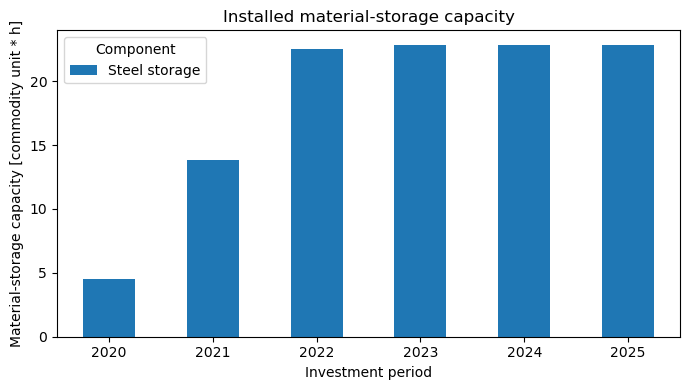

Component,Steel storage
2020,4.549140
2021,13.857210
2022,22.519690
2023,22.835856
2024,22.835856
2025,22.835856


In [49]:
materialStorageCapacities = {}
for year in esM.investmentPeriodNames:
    summary = esM.getOptimizationSummary(
        "MaterialStorageModel", outputLevel=0, ip=year
    )
    capacity = summary.xs("capacity", level="Property")
    materialStorageCapacities[year] = (
        capacity.groupby(level="Component").sum().sum(axis=1)
    )

materialStorageCapacities = pd.DataFrame(materialStorageCapacities).T.fillna(0)
ax = materialStorageCapacities.plot.bar(
    stacked=True, figsize=(7, 4), rot=0
)
ax.set(
    xlabel="Investment period",
    ylabel="Material-storage capacity [commodity unit * h]",
    title="Installed material-storage capacity",
)
plt.tight_layout()
plt.show()
materialStorageCapacities


In [50]:
tolerance = 1e-6
if materialStorageCapacities.abs().to_numpy().max() <= tolerance:
    print("Elastic material supply does not require storage.")
else:
    print("Material storage is built in at least one investment period.")


Material storage is built in at least one investment period.


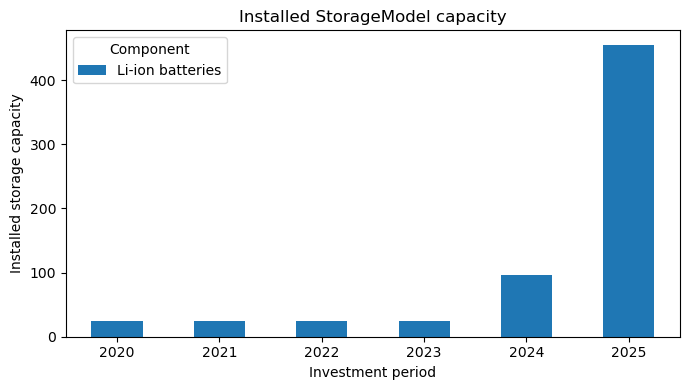

Component,Li-ion batteries
2020,24.619799
2021,24.619799
2022,24.619799
2023,24.619799
2024,96.207900
2025,454.745104


In [51]:
storageCapacities = {}
for year in esM.investmentPeriodNames:
    summary = esM.getOptimizationSummary(
        "StorageModel", outputLevel=0, ip=year
    )
    capacity = summary.xs("capacity", level="Property")
    storageCapacities[year] = (
        capacity.groupby(level="Component").sum().sum(axis=1)
    )

storageCapacities = pd.DataFrame(storageCapacities).T.fillna(0)
ax = storageCapacities.plot.bar(stacked=True, figsize=(7, 4), rot=0)
ax.set(
    xlabel="Investment period",
    ylabel="Installed storage capacity",
    title="Installed StorageModel capacity",
)
plt.tight_layout()
plt.show()
storageCapacities


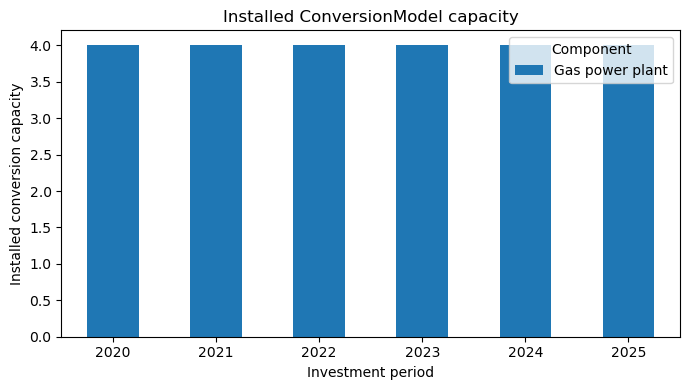

Component,Gas power plant
2020,4.005096
2021,4.005096
2022,4.005096
2023,4.005096
2024,4.005096
2025,4.005096


In [52]:
if "ConversionModel" in esM.componentModelingDict:
    conversionCapacities = {}
    for year in esM.investmentPeriodNames:
        summary = esM.getOptimizationSummary(
            "ConversionModel", outputLevel=0, ip=year
        )
        capacity = summary.xs("capacity", level="Property")
        conversionCapacities[year] = (
            capacity.groupby(level="Component").sum().sum(axis=1)
        )
    conversionCapacities = pd.DataFrame(conversionCapacities).T.fillna(0)
else:
    conversionCapacities = pd.DataFrame(
        {"No conversion capacity": 0.0},
        index=esM.investmentPeriodNames,
    )

ax = conversionCapacities.plot.bar(stacked=True, figsize=(7, 4), rot=0)
ax.set(
    xlabel="Investment period",
    ylabel="Installed conversion capacity",
    title="Installed ConversionModel capacity",
)
plt.tight_layout()
plt.show()
conversionCapacities


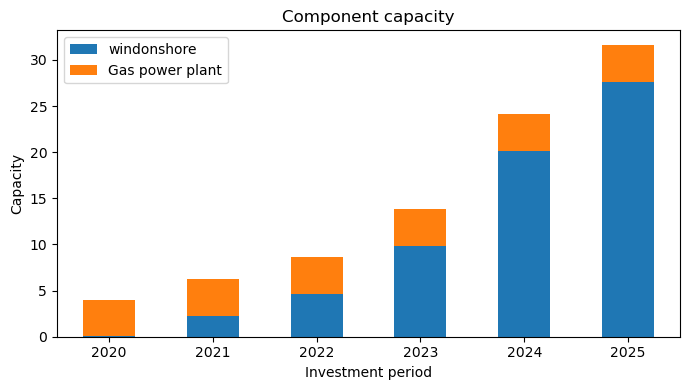

,windonshore,Gas power plant
2020,0.024724,4.005096
2021,2.247928,4.005096
2022,4.679386,4.005096
2023,9.803203,4.005096
2024,20.103346,4.005096
2025,27.621221,4.005096


In [53]:
def plotComponentCapacities(components=None, capacityType="capacity"):
    """Plot installed or commissioned component capacities."""
    if components is None:
        components = [
            componentName
            for modelName in ["SourceSinkModel", "ConversionModel"]
            if modelName in esM.componentModelingDict
            for componentName, component in esM.componentModelingDict[
                modelName
            ].componentsDict.items()
            if isinstance(component, (fn.Source, fn.Conversion))
            and component.hasCapacityVariable
        ]
    if not isinstance(components, list) or not components:
        raise TypeError("components must be a non-empty list.")
    if capacityType not in ["capacity", "commissioning"]:
        raise ValueError(
            "capacityType must be 'capacity' or 'commissioning'."
        )

    modelNames = {}
    for componentName in components:
        component = esM.getComponent(componentName)
        if isinstance(component, fn.Source):
            modelNames[componentName] = "SourceSinkModel"
        elif isinstance(component, fn.Conversion):
            modelNames[componentName] = "ConversionModel"
        else:
            raise TypeError(
                f"{componentName} must be a Source or Conversion component."
            )

    componentCapacities = {}
    for year in esM.investmentPeriodNames:
        componentCapacities[year] = {}
        for componentName, modelName in modelNames.items():
            summary = esM.getOptimizationSummary(
                modelName, outputLevel=0, ip=year
            )
            values = (
                summary.xs(capacityType, level="Property")
                .groupby(level="Component")
                .sum()
                .sum(axis=1)
            )
            if componentName not in values.index:
                raise ValueError(
                    f"{componentName} has no capacity variable."
                )
            componentCapacities[year][componentName] = values[componentName]

    componentCapacities = pd.DataFrame(componentCapacities).T.fillna(0)
    ax = componentCapacities.plot.bar(
        stacked=True, figsize=(7, 4), rot=0
    )
    ax.set(
        xlabel="Investment period",
        ylabel=capacityType.capitalize(),
        title=f"Component {capacityType}",
    )
    plt.tight_layout()
    plt.show()
    return componentCapacities


componentCapacities = plotComponentCapacities(capacityType="capacity")
componentCapacities


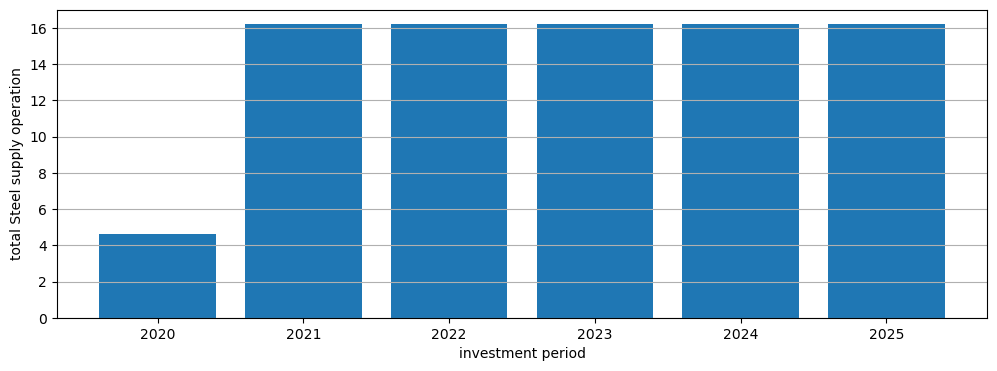

In [54]:
from materialStorageVisualization import (
    plotMaterialStorageOperation,
    plotSourceSinkOperation,
    plotSteelDemandCoverage,
)


fig, ax = plotSourceSinkOperation(
    esM, "Steel supply", style="annualTotals"
)

In [55]:
operation = (
    esM.componentModelingDict["SourceSinkModel"]
    .operationVariablesOptimum[2025]
    .loc[("Steel supply", "GermanyRegion")]
)
operation

0       0.001849
1       0.001849
2       0.001849
3       0.001849
4       0.001849
          ...   
8755    0.001849
8756    0.001849
8757    0.001849
8758    0.001849
8759    0.001849
Name: (Steel supply, GermanyRegion), Length: 8760, dtype: float64

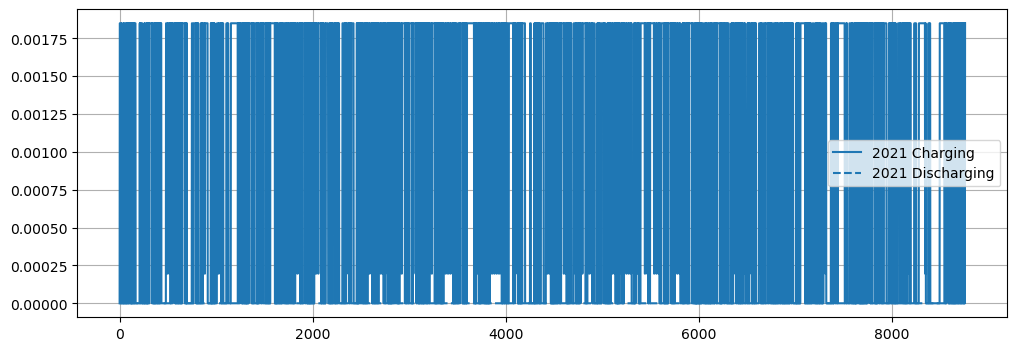

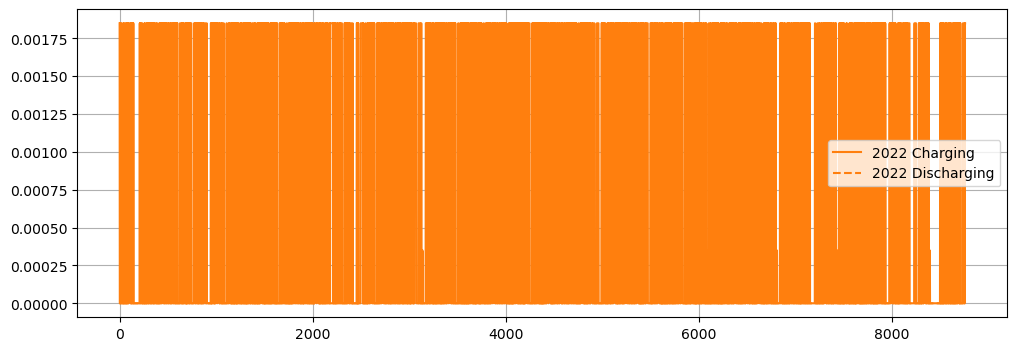

In [56]:
fig, ax = plotMaterialStorageOperation(
    esM, [2021, 2022], separatePlots=True
)

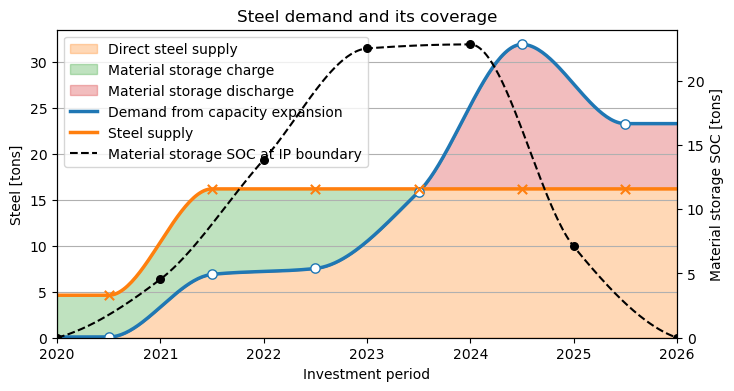

In [57]:
fig, ax = plotSteelDemandCoverage(esM, plotStyle="smooth")

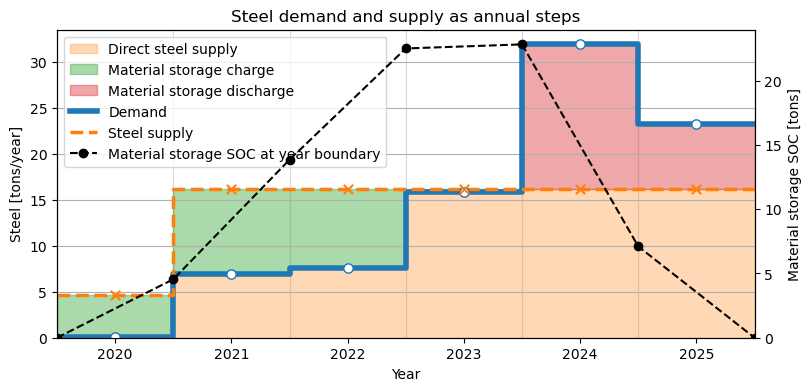

In [58]:
fig, ax = plotSteelDemandCoverage(esM, plotStyle="steps")